In [55]:
%matplotlib widget

In [56]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [57]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     365   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        46   (2094, 964)   float32   


In [58]:
image_cut = image[55:155, 0:1800]
image_error_cut = image_error[55:155, 0:1800]

In [59]:
wv = np.arange(4300.74, 4300.74+1800*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

Text(0.5, 45.40277777777776, 'wavelenght')

In [60]:
z = 0.0238
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

Text(0, 0.5, 'Flux [$10^{-16} erg/(cm^2 s \\AA )$]')

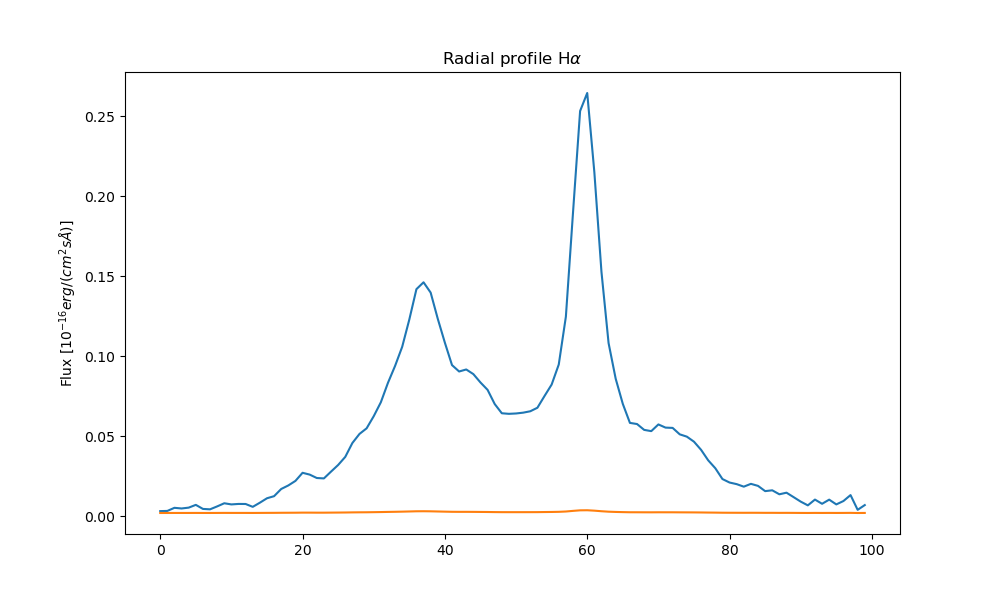

In [61]:
mask_HA = (wv > l_HA-10)*(wv < l_HA+10)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
weights_HA = 1/image_error_HA**2
radial_profile_HA, sum_weights_HA = np.average(image_HA, axis = 1, weights = weights_HA, returned = True)
radial_profile_error_HA = 1/np.sqrt(sum_weights_HA)
#radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))/image_error_HA.shape[1]

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'Radial profile H$\alpha$')
plt.ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')

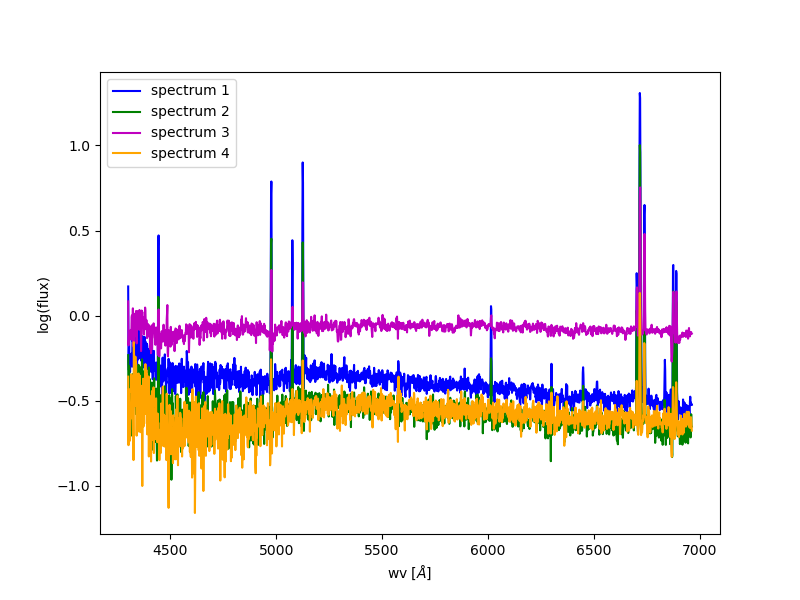

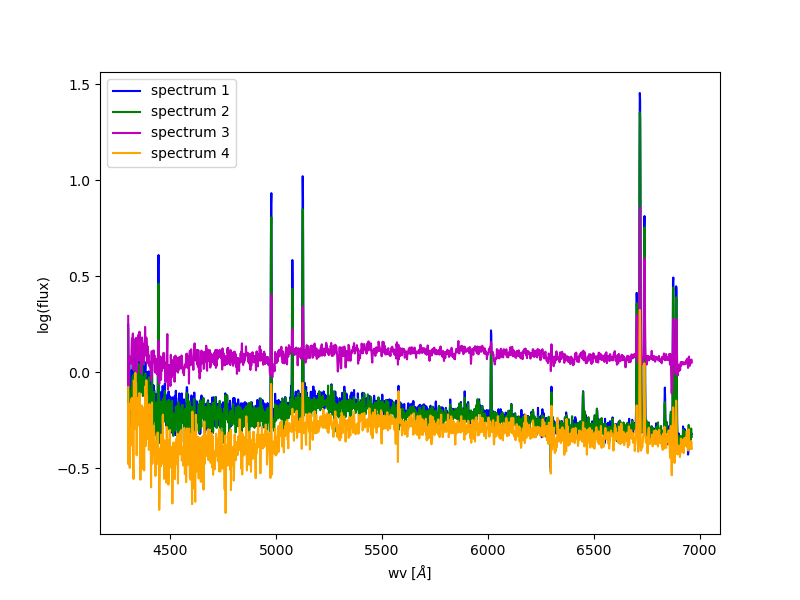

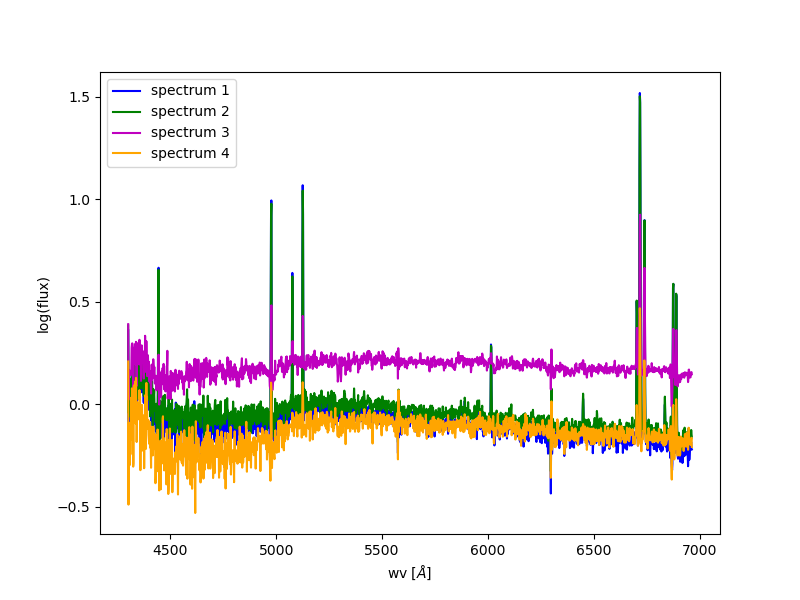

In [62]:
fit_HA = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Fit_code/Halpha_fit.csv")
os.makedirs('1Sigma', exist_ok=True)
os.makedirs('2Sigma', exist_ok=True)
os.makedirs('3Sigma', exist_ok=True)

seeing = 3.17 #in pixels
peaks = fit_HA['x_0']

plt.figure(figsize=(8,6))
spectra_1 =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_err_1 = np.zeros((len(peaks), image_error_cut.shape[1]))
data1 = []
colors = ['blue', 'green', 'm', 'orange']
#Cut one sigma 
for i in range(len(peaks)):
    mask = (x_axes > peaks[i]-seeing)*(x_axes < peaks[i]+seeing)
    spectra_1[i] = np.sum(image_cut[mask, :], axis = 0)
    spectra_err_1[i] = np.sqrt(np.sum(image_error_cut[mask, :]**2, axis = 0)) #The error is the squared sum of the errors of each pixels (y) 
    plt.plot(wv, np.log10(spectra_1[i]), color = colors[i], label = f'spectrum {i+1}')
    plt.legend()
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel('log(flux)')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_1[i].reshape(-1, 1), spectra_err_1[i].reshape(-1, 1)), axis=1)
    data1.append(spectrum_table)
    
np.savetxt(os.path.join('1Sigma', 'Spectrum1s_1'), data1[0])
np.savetxt(os.path.join('1Sigma', 'Spectrum1s_2'), data1[1])
np.savetxt(os.path.join('1Sigma', 'Spectrum1s_3'), data1[2])
np.savetxt(os.path.join('1Sigma', 'Spectrum1s_4'), data1[3])

plt.figure(figsize=(8,6))
spectra_2 =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_err_2 = np.zeros((len(peaks), image_error_cut.shape[1]))
data2 = []

#Cut two sigma 
for i in range(len(peaks)):
    mask = (x_axes > peaks[i]-2*seeing)*(x_axes < peaks[i]+2*seeing)
    spectra_2[i] = np.sum(image_cut[mask, :], axis = 0)
    spectra_err_2[i] = np.sqrt(np.sum(image_error_cut[mask, :]**2, axis = 0)) #The error is the squared sum of the errors of each pixels (y) 
    plt.plot(wv, np.log10(spectra_2[i]), color = colors[i], label = f'spectrum {i+1}')
    plt.legend()
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel('log(flux)')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_2[i].reshape(-1, 1), spectra_err_2[i].reshape(-1, 1)), axis=1)
    data2.append(spectrum_table)
    
np.savetxt(os.path.join('2Sigma', 'Spectrum2s_1'), data2[0])
np.savetxt(os.path.join('2Sigma', 'Spectrum2s_2'), data2[1])
np.savetxt(os.path.join('2Sigma', 'Spectrum2s_3'), data2[2])
np.savetxt(os.path.join('2Sigma', 'Spectrum2s_4'), data2[3])

plt.figure(figsize=(8,6))
spectra_3 =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_err_3 = np.zeros((len(peaks), image_error_cut.shape[1]))
data3 = []
#Cut three sigma 
for i in range(len(peaks)):
    mask = (x_axes > peaks[i]-3*seeing)*(x_axes < peaks[i]+3*seeing)
    spectra_3[i] = np.sum(image_cut[mask, :], axis = 0)
    spectra_err_3[i] = np.sqrt(np.sum(image_error_cut[mask, :]**2, axis = 0)) #The error is the squared sum of the errors of each pixels (y) 
    plt.plot(wv, np.log10(spectra_3[i]), color = colors[i], label = f'spectrum {i+1}')
    plt.legend()
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel('log(flux)')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_3[i].reshape(-1, 1), spectra_err_3[i].reshape(-1, 1)), axis=1)
    data3.append(spectrum_table)
    
np.savetxt(os.path.join('3Sigma', 'Spectrum3s_1'), data3[0])
np.savetxt(os.path.join('3Sigma', 'Spectrum3s_2'), data3[1])
np.savetxt(os.path.join('3Sigma', 'Spectrum3s_3'), data3[2])
np.savetxt(os.path.join('3Sigma', 'Spectrum3s_4'), data3[3])

## S/N continuum
Fare segnale/rumore per ogni pixel e poi fai la media, questo per le tre regioni

In [63]:
import pandas as pd

mask_continuum_1 = (wv > 4500)*(wv < 4800)
mask_continuum_2 = (wv > 5300)*(wv < 5800)
mask_continuum_3 = (wv > 6400)*(wv < 6700)

SNR = []
for i in range(len(peaks)):  
    snr = []
    snr.append(np.mean(spectra_1[i, mask_continuum_1]/spectra_err_1[i, mask_continuum_1])) 
    snr.append(np.mean(spectra_1[i, mask_continuum_2]/spectra_err_1[i, mask_continuum_2])) 
    snr.append(np.mean(spectra_1[i, mask_continuum_3]/spectra_err_1[i, mask_continuum_3])) 
    SNR.append(snr)

SNR_array = np.array(SNR).T  #Trasponi per avere continuum come righe

mean_continuum = np.mean(SNR_array, axis=0)

df = pd.DataFrame(SNR_array, 
                  columns=[f'Spettro_{i+1}' for i in range(4)],
                  index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df.loc['Mean_Continuum'] = mean_continuum

print(df)

df_path = os.path.join('1Sigma', 'SNR_1s_continuum.csv')
df.to_csv(df_path, index=False, float_format='%.3f')

SNR = []
for i in range(len(peaks)):  
    snr = []
    snr.append(np.mean(spectra_2[i, mask_continuum_1]/spectra_err_2[i, mask_continuum_1])) 
    snr.append(np.mean(spectra_2[i, mask_continuum_2]/spectra_err_2[i, mask_continuum_2])) 
    snr.append(np.mean(spectra_2[i, mask_continuum_3]/spectra_err_2[i, mask_continuum_3])) 
    SNR.append(snr)

SNR_array = np.array(SNR).T  #Trasponi per avere continuum come righe

mean_continuum = np.mean(SNR_array, axis=0)

df = pd.DataFrame(SNR_array, 
                  columns=[f'Spettro_{i+1}' for i in range(4)],
                  index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df.loc['Mean_Continuum'] = mean_continuum

print(df)

df_path = os.path.join('2Sigma', 'SNR_2s_continuum.csv')
df.to_csv(df_path, index=False, float_format='%.3f')

SNR = []
for i in range(len(peaks)):  
    snr = []
    snr.append(np.mean(spectra_3[i, mask_continuum_1]/spectra_err_3[i, mask_continuum_1])) 
    snr.append(np.mean(spectra_3[i, mask_continuum_2]/spectra_err_3[i, mask_continuum_2])) 
    snr.append(np.mean(spectra_3[i, mask_continuum_3]/spectra_err_3[i, mask_continuum_3])) 
    SNR.append(snr)

SNR_array = np.array(SNR).T  #Trasponi per avere continuum come righe

mean_continuum = np.mean(SNR_array, axis=0)

df = pd.DataFrame(SNR_array, 
                  columns=[f'Spettro_{i+1}' for i in range(4)],
                  index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df.loc['Mean_Continuum'] = mean_continuum

print(df)

df_path = os.path.join('3Sigma', 'SNR_3s_continuum.csv')
df.to_csv(df_path, index=False, float_format='%.3f')

                Spettro_1  Spettro_2  Spettro_3  Spettro_4
Continuum_1      8.423826   5.378113  15.821598   4.356354
Continuum_2     13.095925   9.942369  25.585195   9.493628
Continuum_3     13.931211  11.016787  30.198015  11.110054
Mean_Continuum  11.816987   8.779089  23.868269   8.320012
                Spettro_1  Spettro_2  Spettro_3  Spettro_4
Continuum_1      9.158180   8.783800  16.514425   5.735597
Continuum_2     15.399173  15.258651  28.225304  12.816451
Continuum_3     16.483107  16.798033  33.550264  14.983514
Mean_Continuum  13.680153  13.613495  26.096664  11.178521
                Spettro_1  Spettro_2  Spettro_3  Spettro_4
Continuum_1      9.411739  10.508991  16.400339   7.148589
Continuum_2     16.904397  18.527504  29.472656  16.065677
Continuum_3     18.128480  20.257645  35.056595  18.952977
Mean_Continuum  14.814872  16.431380  26.976530  14.055748


## S/N emission lines 

In [64]:
z = 0.0238
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

In [65]:
left_region_HA = (wv > 6645) & (wv < 6695)
right_region_HA = (wv > 6750) & (wv < 6800)
clean_mask_HA = left_region_HA | right_region_HA #But also for the two NII lines bc they are closed

mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
wv_bin_HA = np.array(np.where(mask_HA == True))
mask_HB = (wv > l_HB-8)*(wv < l_HB+8)
mask_NII = (wv > l_NII-8)*(wv < l_NII+8)
mask_SII = (wv > l_SII-8)*(wv < l_SII+8)
mask_OIII = (wv > l_OIII-8)*(wv < l_OIII+8)

signal_HA_1s = []
noise_HA_1s = []
SNR_HA_1s = []
for i in range(len(peaks)):
    flux_HA = spectra_1[i, mask_HA] - np.mean(spectra_1[i, clean_mask_HA])
    signal = (np.trapz(flux_HA, wv[mask_HA]))
    noise = np.std(spectra_1[i, clean_mask_HA] - np.mean(spectra_1[i, clean_mask_HA]))*1.48*np.sqrt(wv_bin_HA.shape[1]) #std*delta(wv)*number of A under the line
    SNR_HA_1s.append(signal/noise)
    signal_HA_1s.append(signal)
    noise_HA_1s.append(noise)

print(signal_HA_1s)
print(noise_HA_1s)
print(SNR_HA_1s)


[80.59326540737722, 39.525604499373976, 18.9359440718623, 4.20208162749391]
[0.11480471788214255, 0.07996129732277615, 0.1417874803708743, 0.10810835369001584]
[702.0030787420558, 494.3091948573915, 133.55159441673865, 38.869166757850515]


In [66]:
a =np.array(np.where(mask_HA == True))
a.shape[1]

11

In [67]:
np.where(mask_HA == True)

(array([1629, 1630, 1631, 1632, 1633, 1634, 1635, 1636, 1637, 1638, 1639],
       dtype=int64),)